## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health? 

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LassoCV

In [21]:
### Question 1

df = pd.read_csv("./data/golub.csv")

mapper = {'allB': 0, 'allT': 0, 'aml': 1}

df['y'] = df['cancer'].map(mapper)

genes = df.drop(['Samples', 'cancer', 'Gender', 'y', 'Source', 'tissue.mf', 'BM.PB'], axis=1)
y = df['y']

MSE: 4.361503750502543e-30
count    7.200000e+01
mean     7.555684e-17
std      2.101700e-15
min     -9.325873e-15
25%     -5.551115e-16
50%      2.220446e-16
75%      1.471046e-15
max      3.885781e-15
Name: y, dtype: float64


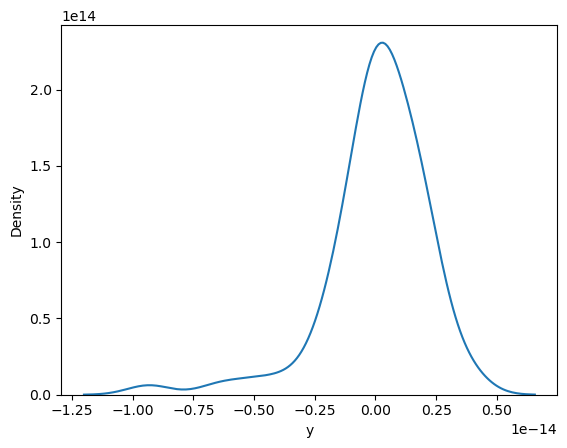

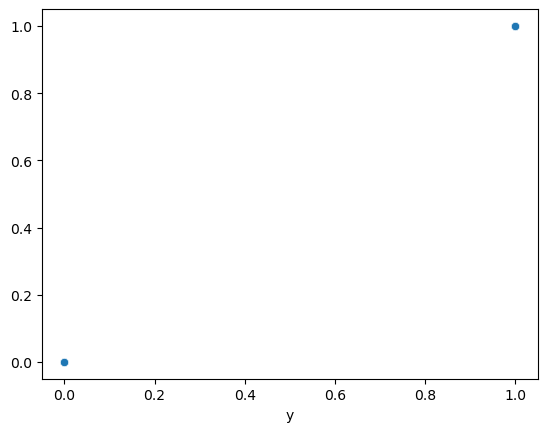

In [22]:
### Question 2

model = LinearRegression()
model = model.fit(genes, y)

y_hat = model.predict(genes)

mse = mean_squared_error(y, y_hat)
print("MSE:", mse) # The MSE is 4.36e-30

resid = y - y_hat
print(resid.describe())
sns.kdeplot(resid)
plt.show()
sns.scatterplot(x=y, y=y_hat)
plt.show()

In [23]:
# Question 3

scores = cross_val_score(model, genes, y, cv=5, scoring="neg_mean_squared_error")
cv_mse = -scores.mean()
print("Cross-validated MSE:", cv_mse)

Cross-validated MSE: 0.06009395647748037


The MSE after doing cross validation is much higher than the training MSE, indicating that the model is overfitting. Since there are many more features than observations, the model fits the training data very well but does not generalize well to new data, which reflects a high variance model in the bias-variance tradeoff.

HG3549-HT3751_at   -1.866398e-06
J04164_at          -2.975928e-06
L38941_at           9.359366e-07
M11147_at           9.651806e-07
M11722_at          -1.175811e-06
M17733_at          -3.027364e-06
M19507_at           1.150747e-05
M26602_at          -2.373871e-06
M27891_at           1.000528e-05
M33680_at          -1.070980e-06
M63138_at           1.294145e-05
M77232_rna1_at      4.205801e-07
M91036_rna1_at      2.704303e-06
M96326_rna1_at      3.045484e-06
U14968_at           1.377602e-06
X04500_at          -3.948526e-07
X17042_at           8.734762e-06
X78992_at           2.598685e-06
Z70759_at           1.289107e-06
L06797_s_at        -2.527830e-06
D49824_s_at        -1.121923e-07
M25079_s_at         4.082125e-07
X57351_s_at        -1.190599e-06
V00594_s_at        -1.685259e-06
U05255_s_at         1.146583e-05
X03689_s_at        -7.578508e-07
M14328_s_at         1.777423e-06
M14483_rna1_s_at   -1.758451e-06
M26708_s_at        -7.132857e-07
Y00787_s_at         5.454046e-06
Z19554_s_a

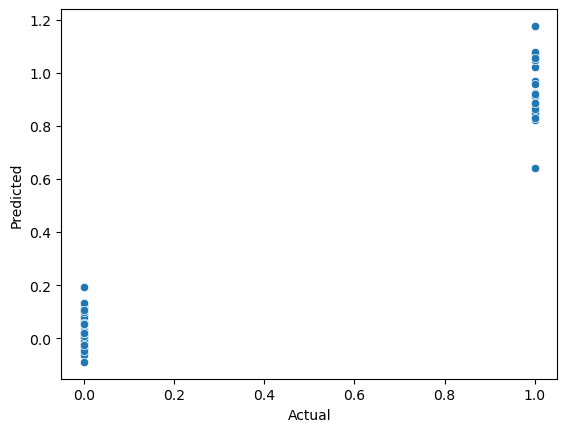

In [5]:
# Question 4

lasso = LassoCV(cv=5)
lasso.fit(genes, y)

y_hat_lasso = lasso.predict(genes)

coef = pd.Series(lasso.coef_, index=genes.columns)
selected_genes = coef[coef != 0]  # set of selected genes (the ones with non-zero coefficients)
print(selected_genes)

print("Number of selected genes:", len(selected_genes))  # 34 genes were selected, while 7095 were discarded
print("Number of discarded genes:", (coef == 0).sum())

sns.scatterplot(x=y, y=y_hat_lasso)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

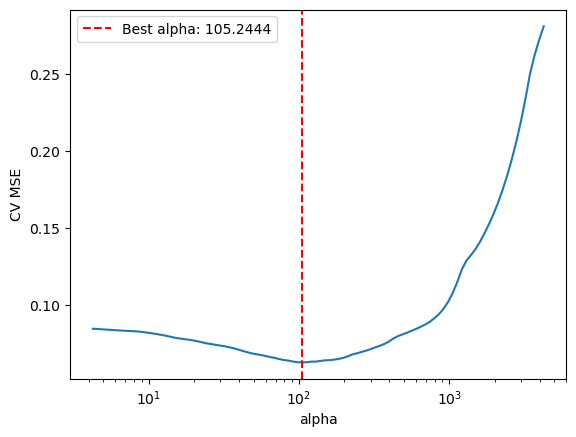

Best alpha: 105.24436668425457


In [ ]:
### Question 5

alphas = lasso.alphas_
mse_path = lasso.mse_path_.mean(axis=1)

plt.plot(alphas, mse_path)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("CV MSE")
plt.axvline(lasso.alpha_, color="red", linestyle="--", label=f"Best alpha: {lasso.alpha_:.4f}")
plt.legend()
plt.show()

print("Best alpha:", lasso.alpha_)

The model overfits for alpha values that are very small (like below 10), underfits for larger alpha values (above around 10^3), and performs best at alpha ≈ 105 where the cross-validated MSE is minimized.

##### Question 6
Linear regression performs almost perfectly on the training set because there are far more gene variables than patients, so the model has enough flexibility to fit the training data extremely closely. However, this leads to overfitting, meaning it captures noise rather than patterns to be able to generalize well. The LASSO adds a penalty that shrinks many coefficients to zero, which reduces model complexity and keeps only the most useful genes. As a result, it does not fit the training data as perfectly, but it makes better predictions on new data since the model can generalize more.

#### Question 7

Regularization methods are well-suited to precision health because these problems often involve very large numbers of predictors (genes, biomarkers, clinical measurements, etc.) but relatively small numbers of patients. In cases like this, regression can cause overfitting. However, regularization helps control model complexity, reduces variance, and improves prediction on new patients, just like how LASSO in this case helped narrow down to the most important predictors.

#### Question 8

Using methods like LASSO for precision health problems can lead to ethical concerns since the outcomes of these models would directly impact patient care. If LASSO discards variables that are important or places emphasis on variables that are not as relevant, it could move interventions in the wrong direction.